# CASALS public S3 data inventory

This notebook inventories object metadata under the public **casals-data/lidar/** prefix using anonymous, paginated S3 **ListObjectsV2** requests. It also checks per-object read authorization with **HeadObject**. It never downloads or reads object contents.

The listing is limited to this public prefix. Product levels are recognized from explicit filename markers; **LastModified** is not treated as an acquisition date. Source: [NASA CASALS L1B Waveform Data Tutorial](https://book.cryointhecloud.com/l1b-waveforms-tutorial/).

Requires **boto3**, **pandas**, and **matplotlib** (install with **python -m pip install boto3 pandas matplotlib** if needed). Run from the project root or any working directory; no project modules or AWS credentials are used.

## Connect and list all objects

The paginator follows every continuation token. Directory placeholders with zero size are omitted; real zero-byte objects are retained.

In [1]:
from datetime import date, datetime, timezone
from pathlib import PurePosixPath
import re

import boto3
import matplotlib.pyplot as plt
import pandas as pd
from botocore import UNSIGNED
from botocore.config import Config
from botocore.exceptions import BotoCoreError, ClientError
from IPython.display import display

BUCKET = "casals-data"
PREFIX = "lidar/"
BYTES_PER_GIB = 2**30
BYTES_PER_TIB = 2**40

s3 = boto3.client(
    "s3",
    region_name="us-west-2",
    config=Config(signature_version=UNSIGNED),
)

ALLOWED_S3_OPERATIONS = {"ListObjectsV2", "HeadObject"}

def enforce_allowed_s3_operations(model, **kwargs):
    if model.name not in ALLOWED_S3_OPERATIONS:
        raise RuntimeError(f"Blocked unexpected S3 operation: {model.name}")

s3.meta.events.register("before-call.s3", enforce_allowed_s3_operations)
paginator = s3.get_paginator("list_objects_v2")
object_rows = []
page_count = 0

try:
    for page in paginator.paginate(Bucket=BUCKET, Prefix=PREFIX):
        page_count += 1
        for obj in page.get("Contents", []):
            key = obj["Key"]
            size = int(obj["Size"])
            if key.endswith("/") and size == 0:
                continue
            object_rows.append({
                "Key": key,
                "Size (bytes)": size,
                "LastModified": obj.get("LastModified"),
                "StorageClass": obj.get("StorageClass"),
            })
except ClientError as exc:
    error = exc.response.get("Error", {})
    code = error.get("Code", "Unknown")
    message = error.get("Message", str(exc))
    hints = {
        "AccessDenied": "Anonymous ListObjectsV2 access was denied; no inventory was produced.",
        "NoSuchBucket": "The configured bucket was not found; no inventory was produced.",
        "SlowDown": "S3 throttled the listing; retry the notebook later.",
        "RequestTimeout": "S3 timed out the listing; retry the notebook later.",
    }
    print(f"ListObjectsV2 failed [{code}]: {message}")
    if code in hints:
        print(hints[code])
    raise
except BotoCoreError as exc:
    code = type(exc).__name__
    print(f"ListObjectsV2 failed [{code}]: {str(exc).splitlines()[0]}")
    print("The S3 listing did not complete; no zero-file result is reported.")
    raise

inventory_timestamp_utc = datetime.now(timezone.utc)
print(f"Completed {page_count} ListObjectsV2 page(s); retained {len(object_rows):,} non-placeholder object(s).")

Completed 27 ListObjectsV2 page(s); retained 26,418 non-placeholder object(s).


## Parse metadata and classify names

Acquisition dates come only from a valid **lidar/YYYY-MM-DD/** directory. Product levels come only from explicit, case-insensitive filename markers. Other files remain in the inventory.

In [2]:
LEVEL_ORDER = ["L0", "L1A", "L1B", "L2A", "L2B", "ARD", "Other / Unknown"]
PRODUCT_PATTERN = re.compile(r"(?<![A-Z0-9])(L1A|L1B|L2A|L2B|L0|ARD)(?![A-Z0-9])", re.IGNORECASE)
LEVEL2_PATTERN = re.compile(
    r"(?<![A-Z0-9])(?:L2(?:[A-Z])?|LEVEL[\s_-]*2(?:[A-Z])?)(?![A-Z0-9])",
    re.IGNORECASE,
)

def acquisition_date_from_key(key):
    relative_key = key[len(PREFIX):] if key.startswith(PREFIX) else key
    if "/" not in relative_key:
        return "Unknown"
    directory = relative_key.split("/", 1)[0]
    if not re.fullmatch(r"\d{4}-\d{2}-\d{2}", directory):
        return "Unknown"
    try:
        return date.fromisoformat(directory).isoformat()
    except ValueError:
        return "Unknown"

def product_level_from_name(filename):
    match = PRODUCT_PATTERN.search(filename)
    if not match:
        return "Other / Unknown"
    token = match.group(1).upper()
    return {"L0": "L0", "L1A": "L1A", "L1B": "L1B", "L2A": "L2A", "L2B": "L2B", "ARD": "ARD"}[token]

def has_explicit_level2_marker(filename):
    return bool(LEVEL2_PATTERN.search(filename))

inventory = pd.DataFrame(
    object_rows,
    columns=["Key", "Size (bytes)", "LastModified", "StorageClass"],
)
inventory["Size (bytes)"] = pd.to_numeric(inventory["Size (bytes)"], errors="raise").astype("int64")
inventory["Acquisition date"] = inventory["Key"].map(acquisition_date_from_key)
inventory["Product level"] = inventory["Key"].map(
    lambda key: product_level_from_name(PurePosixPath(key).name)
)
inventory["File format"] = inventory["Key"].map(
    lambda key: PurePosixPath(key).suffix.lower() or "No extension"
)
inventory["Explicit Level-2 marker"] = inventory["Key"].map(
    lambda key: has_explicit_level2_marker(PurePosixPath(key).name)
)

total_bytes = int(inventory["Size (bytes)"].sum())
assert len(inventory) == len(object_rows)
assert total_bytes == sum(row["Size (bytes)"] for row in object_rows)
print(f"Inventory DataFrame: {len(inventory):,} objects; {total_bytes:,} bytes.")

Inventory DataFrame: 26,418 objects; 3,432,133,618,446 bytes.


## A. Storage overview

Recognized acquisition-date totals exclude **Unknown**; the date range is not inferred from S3 modification timestamps.

In [3]:
known_dates = sorted(d for d in inventory["Acquisition date"].unique() if d != "Unknown")
observed_levels = [level for level in LEVEL_ORDER if level != "Other / Unknown" and level in set(inventory["Product level"])]
if "Other / Unknown" in set(inventory["Product level"]):
    observed_levels.append("Other / Unknown")

overview = pd.DataFrame(
    [
        ("Bucket", BUCKET),
        ("Query prefix", PREFIX),
        ("Inventory timestamp (UTC)", inventory_timestamp_utc.isoformat()),
        ("ListObjectsV2 pages", page_count),
        ("Objects (zero-byte directory placeholders excluded)", len(inventory)),
        ("Total size (bytes)", f"{total_bytes:,}"),
        ("Total size (GiB, 2^30 bytes)", f"{total_bytes / BYTES_PER_GIB:,.3f}"),
        ("Total size (TiB, 2^40 bytes)", f"{total_bytes / BYTES_PER_TIB:,.4f}"),
        ("Earliest acquisition date", known_dates[0] if known_dates else "Unknown"),
        ("Latest acquisition date", known_dates[-1] if known_dates else "Unknown"),
        ("Distinct recognized acquisition dates", len(known_dates)),
        ("Product levels observed", ", ".join(observed_levels) if observed_levels else "None identified"),
    ],
    columns=["Measure", "Value"],
)
display(overview)

,Measure,Value
0,Bucket,casals-data
1,Query prefix,lidar/
2,Inventory timestamp (UTC),2026-10-10T22:42:26.160963+00:00
3,ListObjectsV2 pages,27
4,Objects (zero-byte directory placeholders excl...,26418
5,Total size (bytes),"3,432,133,618,446"
6,"Total size (GiB, 2^30 bytes)","3,196.424"
7,"Total size (TiB, 2^40 bytes)",3.1215
8,Earliest acquisition date,2024-11-12
9,Latest acquisition date,2024-11-18


## B. Inventory by product level

Percentages use the total listed object size. Standard levels with no matches remain visible with zero values; this says nothing about other buckets or non-public storage.

In [4]:
product_summary = (
    inventory.groupby("Product level", dropna=False)
    .agg(**{"Number of files": ("Key", "size"), "Total size (bytes)": ("Size (bytes)", "sum")})
    .reindex(LEVEL_ORDER, fill_value=0)
)
product_summary["Total size (GiB)"] = product_summary["Total size (bytes)"] / BYTES_PER_GIB
product_summary["Percentage of storage"] = (
    100 * product_summary["Total size (bytes)"] / total_bytes if total_bytes else 0.0
)
product_summary = product_summary[
    ["Number of files", "Total size (GiB)", "Percentage of storage"]
].reset_index(names="Product level")
product_summary["Total size (GiB)"] = product_summary["Total size (GiB)"].round(3)
product_summary["Percentage of storage"] = product_summary["Percentage of storage"].round(2)
assert int(product_summary["Number of files"].sum()) == len(inventory)
display(product_summary)

format_summary = (
    inventory.groupby("File format", dropna=False)
    .agg(**{"Number of files": ("Key", "size"), "Total size (bytes)": ("Size (bytes)", "sum")})
    .sort_values("Total size (bytes)", ascending=False)
)
format_summary["Total size (GiB)"] = (format_summary["Total size (bytes)"] / BYTES_PER_GIB).round(3)
format_summary = format_summary[["Number of files", "Total size (GiB)"]].reset_index()
print("File-format summary")
display(format_summary)

,Product level,Number of files,Total size (GiB),Percentage of storage
0,L0,0,0.000,0.00
1,L1A,0,0.000,0.00
2,L1B,26409,3153.387,98.65
3,L2A,0,0.000,0.00
4,L2B,0,0.000,0.00
5,ARD,0,0.000,0.00
6,Other / Unknown,9,43.037,1.35


File-format summary


,File format,Number of files,Total size (GiB)
0,.h5,273,3135.061
1,.m4v,4,43.001
2,.png,18936,18.322
3,.kml,7204,0.040
4,.txt,1,0.000


## C. Inventory by acquisition date

The date summary includes an **Unknown** row when a key has no valid date directory. The cross-tab reports file counts for each product level and date.

Files and storage by acquisition date


,Acquisition date,File count,Total size (GiB)
0,2024-11-12,6296,1114.586
1,2024-11-18,10687,2023.426
2,Unknown,9435,58.412


File count by acquisition date and product level


Product level,Acquisition date,L0,L1A,L1B,L2A,L2B,ARD,Other / Unknown
0,2024-11-12,0,0,6296,0,0,0,0
1,2024-11-18,0,0,10687,0,0,0,0
2,Unknown,0,0,9426,0,0,0,9


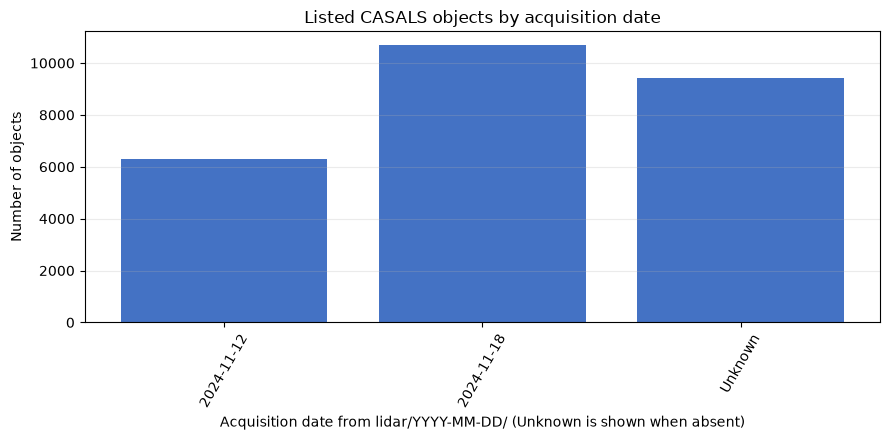

In [5]:
date_summary = (
    inventory.groupby("Acquisition date", dropna=False)
    .agg(**{"File count": ("Key", "size"), "Total size (bytes)": ("Size (bytes)", "sum")})
)
date_summary["Total size (GiB)"] = (date_summary["Total size (bytes)"] / BYTES_PER_GIB).round(3)
date_summary = date_summary[["File count", "Total size (GiB)"]].reset_index()

date_level_counts = pd.crosstab(inventory["Acquisition date"], inventory["Product level"])
date_level_counts = date_level_counts.reindex(columns=LEVEL_ORDER, fill_value=0)
date_order = known_dates + (["Unknown"] if "Unknown" in set(inventory["Acquisition date"]) else [])
date_summary = date_summary.set_index("Acquisition date").reindex(date_order).reset_index()
date_level_counts = date_level_counts.reindex(date_order, fill_value=0)

print("Files and storage by acquisition date")
display(date_summary)
print("File count by acquisition date and product level")
display(date_level_counts.reset_index())

if len(date_summary):
    chart_width = min(22, max(9, 0.42 * len(date_summary)))
    fig, ax = plt.subplots(figsize=(chart_width, 4.5))
    ax.bar(date_summary["Acquisition date"], date_summary["File count"], color="#4472C4")
    ax.set_title("Listed CASALS objects by acquisition date")
    ax.set_xlabel("Acquisition date from lidar/YYYY-MM-DD/ (Unknown is shown when absent)")
    ax.set_ylabel("Number of objects")
    ax.grid(axis="y", alpha=0.25)
    tick_step = max(1, len(date_summary) // 24)
    ax.set_xticks(range(0, len(date_summary), tick_step))
    ax.tick_params(axis="x", rotation=60)
    fig.tight_layout()
    plt.show()
else:
    print("No non-placeholder objects were returned for this prefix.")

## D. Directory structure

This groups every listed object under its immediate child of **lidar/**. Files directly in **lidar/** are shown as root objects.

In [6]:
def immediate_child(key):
    relative_key = key[len(PREFIX):] if key.startswith(PREFIX) else key
    if "/" not in relative_key:
        return f"{PREFIX}(root)"
    return f"{PREFIX}{relative_key.split('/', 1)[0]}/"

inventory["Immediate child prefix"] = inventory["Key"].map(immediate_child)
directory_summary = (
    inventory.groupby("Immediate child prefix", dropna=False)
    .agg(**{"Object count": ("Key", "size"), "Total size (bytes)": ("Size (bytes)", "sum")})
    .sort_values(["Object count", "Total size (bytes)"], ascending=False)
)
directory_summary["Total size (GiB)"] = (directory_summary["Total size (bytes)"] / BYTES_PER_GIB).round(3)
directory_summary = directory_summary[["Object count", "Total size (GiB)"]].reset_index()
assert int(directory_summary["Object count"].sum()) == len(inventory)
display(directory_summary)

,Immediate child prefix,Object count,Total size (GiB)
0,lidar/2024-11-18/,10687,2023.426
1,lidar/Google_Earth_Tour/,9431,15.411
2,lidar/2024-11-12/,6296,1114.586
3,lidar/(root),4,43.001


## E. File inventory

**s3_inventory** retains all listed object metadata and parsed fields for interactive filtering. The default preview is limited to 20 rows.

In [7]:
s3_inventory = inventory.copy()
with pd.option_context("display.max_colwidth", None):
    display(s3_inventory.head(20))

largest_columns = ["Key", "Product level", "Acquisition date", "Size (bytes)", "LastModified"]
largest_20 = s3_inventory.nlargest(20, "Size (bytes)")[largest_columns].copy()
largest_20["Size (GiB)"] = (largest_20["Size (bytes)"] / BYTES_PER_GIB).round(3)
largest_20 = largest_20[["Key", "Product level", "Acquisition date", "Size (GiB)", "LastModified"]]
print("20 largest listed objects")
with pd.option_context("display.max_colwidth", None):
    display(largest_20)

,Key,Size (bytes),LastModified,StorageClass,Acquisition date,Product level,File format,Explicit Level-2 marker,Immediate child prefix
0,lidar/2024-11-12/casals_l1b_20241112T163923_001_02.h5,3265927272,2025-12-11 15:02:45+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
1,lidar/2024-11-12/casals_l1b_20241112T163934_001_02.h5,1400700828,2025-12-11 15:02:45+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
2,lidar/2024-11-12/casals_l1b_20241112T163941_001_02.h5,1686318835,2025-12-11 15:02:45+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
3,lidar/2024-11-12/casals_l1b_20241112T164250_001_02.h5,13937434321,2025-12-11 15:09:39+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
4,lidar/2024-11-12/casals_l1b_20241112T164315_001_02.h5,13902043088,2025-12-11 15:09:39+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
5,lidar/2024-11-12/casals_l1b_20241112T164340_001_02.h5,13874478868,2025-12-11 15:09:39+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
6,lidar/2024-11-12/casals_l1b_20241112T164406_001_02.h5,13976438011,2025-12-11 15:09:39+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
7,lidar/2024-11-12/casals_l1b_20241112T164431_001_02.h5,13963454127,2025-12-11 15:09:39+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
8,lidar/2024-11-12/casals_l1b_20241112T164456_001_02.h5,1019179723,2025-12-11 15:18:02+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
9,lidar/2024-11-12/casals_l1b_20241112T164916_001_02.h5,13944626497,2025-12-11 15:18:46+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/


20 largest listed objects


,Key,Product level,Acquisition date,Size (GiB),LastModified
16985,lidar/CASALS_2024-11-18_All_Amplitudes_Tour.m4v,Other / Unknown,Unknown,14.008,2026-01-20 18:35:40+00:00
16986,lidar/CASALS_2024-11-18_All_Heights_Tour.m4v,Other / Unknown,Unknown,13.996,2026-01-20 18:35:40+00:00
6420,lidar/2024-11-18/casals_l1b_20241118T172515_001_02.h5,L1B,2024-11-18,13.185,2025-12-12 17:06:06+00:00
11,lidar/2024-11-12/casals_l1b_20241112T165006_001_02.h5,L1B,2024-11-12,13.152,2025-12-11 15:20:13+00:00
38,lidar/2024-11-12/casals_l1b_20241112T171847_001_02.h5,L1B,2024-11-12,13.134,2025-12-11 16:10:09+00:00
6421,lidar/2024-11-18/casals_l1b_20241118T172541_001_02.h5,L1B,2024-11-18,13.134,2025-12-12 17:07:37+00:00
6411,lidar/2024-11-18/casals_l1b_20241118T171757_001_02.h5,L1B,2024-11-18,13.115,2025-12-12 16:49:55+00:00
6406,lidar/2024-11-18/casals_l1b_20241118T171552_001_02.h5,L1B,2024-11-18,13.114,2025-12-12 16:39:44+00:00
6413,lidar/2024-11-18/casals_l1b_20241118T172006_001_02.h5,L1B,2024-11-18,13.112,2025-12-12 16:56:01+00:00
25,lidar/2024-11-12/casals_l1b_20241112T170442_001_02.h5,L1B,2024-11-12,13.104,2025-12-11 15:47:54+00:00


## F. Check two locally used H5 filenames

This lookup uses inventory key basenames only and does not inspect any local or remote H5 contents.

In [8]:
historical_sizes = {
    "casals_l1b_20241112T165718_001_02.h5": 14_082_437_919,
    "casals_l1b_20241118T171757_001_02.h5": 14_039_701_685,
}
lookup_rows = []
for filename, historical_size in historical_sizes.items():
    matches = s3_inventory[
        s3_inventory["Key"].map(lambda key: PurePosixPath(key).name == filename)
    ]
    if matches.empty:
        lookup_rows.append({
            "Filename": filename,
            "Found on S3": False,
            "S3 Key": None,
            "Size (bytes)": None,
            "Historical size (bytes)": historical_size,
            "Size matches history": None,
        })
    else:
        for _, match in matches.iterrows():
            lookup_rows.append({
                "Filename": filename,
                "Found on S3": True,
                "S3 Key": match["Key"],
                "Size (bytes)": int(match["Size (bytes)"]),
                "Historical size (bytes)": historical_size,
                "Size matches history": int(match["Size (bytes)"]) == historical_size,
            })
local_file_lookup = pd.DataFrame(lookup_rows)
with pd.option_context("display.max_colwidth", None):
    display(local_file_lookup)

print(
    "A matching filename and size supports object correspondence only; it does not by itself "
    "establish the route by which a local file was downloaded."
)

,Filename,Found on S3,S3 Key,Size (bytes),Historical size (bytes),Size matches history
0,casals_l1b_20241112T165718_001_02.h5,True,lidar/2024-11-12/casals_l1b_20241112T165718_001_02.h5,14039701685,14082437919,False
1,casals_l1b_20241118T171757_001_02.h5,True,lidar/2024-11-18/casals_l1b_20241118T171757_001_02.h5,14082437919,14039701685,False


A matching filename and size supports object correspondence only; it does not by itself establish the route by which a local file was downloaded.


## G. Level-2 availability

Level-2 detection checks explicit filename markers such as **L2**, **L2A**, **L2B**, or **LEVEL-2**. The search scope is only this public S3 prefix.

In [9]:
level2_inventory = s3_inventory[s3_inventory["Explicit Level-2 marker"]].copy()

if level2_inventory.empty:
    print("No Level-2 objects were identified under the scanned S3 prefix.")
else:
    level2_display = level2_inventory[
        ["Key", "Product level", "Size (bytes)", "LastModified", "Acquisition date"]
    ].copy()
    level2_display["Size (GiB)"] = (level2_display["Size (bytes)"] / BYTES_PER_GIB).round(3)
    print(f"Identified {len(level2_display):,} Level-2-marked object(s) under {BUCKET}/{PREFIX}.")
    with pd.option_context("display.max_colwidth", None):
        display(level2_display[["Key", "Product level", "Size (bytes)", "Size (GiB)", "LastModified", "Acquisition date"]])

No Level-2 objects were identified under the scanned S3 prefix.


## H. Object read-access status

This performs one anonymous **HeadObject** request for each listed key. It requests metadata only and does not retrieve object bytes. For general-purpose S3 buckets, AWS requires `s3:GetObject` permission for `HeadObject`, so a successful response confirms current read authorization for that key. The response also reports archive and restore status, which can affect immediate retrieval. This does not test a complete byte transfer or file integrity. See the [AWS HeadObject API](https://docs.aws.amazon.com/AmazonS3/latest/API/API_HeadObject.html).

In [10]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from time import monotonic

HEAD_WORKERS = 8
head_rows = s3_inventory[["Key", "Size (bytes)", "StorageClass"]].to_dict("records")

def check_object_read_access(row):
    try:
        response = s3.head_object(Bucket=BUCKET, Key=row["Key"])
        http_status = response.get("ResponseMetadata", {}).get("HTTPStatusCode")
        storage_class = response.get("StorageClass") or row["StorageClass"]
        archive_status = response.get("ArchiveStatus")
        restore_status = response.get("Restore")
        archived = (
            storage_class in {"GLACIER", "DEEP_ARCHIVE"}
            or archive_status in {"ARCHIVE_ACCESS", "DEEP_ARCHIVE_ACCESS"}
        )
        if not archived:
            availability = "Readable now"
        elif restore_status and re.search(r'ongoing-request\s*=\s*"false"', restore_status, re.IGNORECASE):
            availability = "Restored; readable temporarily"
        elif restore_status and re.search(r'ongoing-request\s*=\s*"true"', restore_status, re.IGNORECASE):
            availability = "Restore in progress"
        else:
            availability = "Archived; not currently readable"

        return {
            "Key": row["Key"],
            "HeadObject status": "Success" if http_status == 200 else f"HTTP {http_status}",
            "HTTP status": http_status,
            "Error code": None,
            "Error message": None,
            "Listed size (bytes)": int(row["Size (bytes)"]),
            "HeadObject size (bytes)": response.get("ContentLength"),
            "Size matches listing": response.get("ContentLength") == int(row["Size (bytes)"]),
            "StorageClass": storage_class,
            "ArchiveStatus": archive_status,
            "Restore": restore_status,
            "Availability now": availability,
        }
    except ClientError as exc:
        error = exc.response.get("Error", {})
        metadata = exc.response.get("ResponseMetadata", {})
        code = error.get("Code", "Unknown")
        http_status = metadata.get("HTTPStatusCode")
        return {
            "Key": row["Key"],
            "HeadObject status": "Access denied" if http_status == 403 or code == "AccessDenied" else "Request failed",
            "HTTP status": http_status,
            "Error code": code,
            "Error message": error.get("Message", str(exc)),
            "Listed size (bytes)": int(row["Size (bytes)"]),
            "HeadObject size (bytes)": None,
            "Size matches listing": None,
            "StorageClass": row["StorageClass"],
            "ArchiveStatus": None,
            "Restore": None,
            "Availability now": "Unknown",
        }
    except BotoCoreError as exc:
        return {
            "Key": row["Key"],
            "HeadObject status": "Request error",
            "HTTP status": None,
            "Error code": type(exc).__name__,
            "Error message": str(exc).splitlines()[0],
            "Listed size (bytes)": int(row["Size (bytes)"]),
            "HeadObject size (bytes)": None,
            "Size matches listing": None,
            "StorageClass": row["StorageClass"],
            "ArchiveStatus": None,
            "Restore": None,
            "Availability now": "Unknown",
        }

head_results = [None] * len(head_rows)
started = monotonic()
with ThreadPoolExecutor(max_workers=HEAD_WORKERS) as executor:
    pending = {
        executor.submit(check_object_read_access, row): index
        for index, row in enumerate(head_rows)
    }
    for completed, future in enumerate(as_completed(pending), start=1):
        head_results[pending[future]] = future.result()
        if completed % 1000 == 0 or completed == len(pending):
            print(f"HeadObject checks completed: {completed:,}/{len(pending):,}")

head_inventory = pd.DataFrame(head_results)
download_access_inventory = s3_inventory.merge(
    head_inventory, on="Key", how="left", validate="one_to_one"
)
head_success = head_inventory["HeadObject status"].eq("Success")
currently_readable = head_inventory["Availability now"].isin(
    ["Readable now", "Restored; readable temporarily"]
)
size_mismatches = head_inventory["Size matches listing"].eq(False)
head_failures = head_inventory.loc[~head_success].copy()
archive_unavailable = head_inventory["Availability now"].isin(
    ["Restore in progress", "Archived; not currently readable"]
).sum()

download_access_summary = pd.DataFrame(
    [
        ("Objects in the S3 listing", len(s3_inventory)),
        ("HeadObject checks completed", int(head_inventory["HeadObject status"].notna().sum())),
        ("HeadObject successes", int(head_success.sum())),
        ("HeadObject failures or request errors", int((~head_success).sum())),
        ("Objects readable now (including restored archives)", int(currently_readable.sum())),
        ("Archived objects not currently readable", int(archive_unavailable)),
        ("HeadObject sizes differing from listing", int(size_mismatches.sum())),
        (
            "All listed objects pass the read-access and current-availability checks",
            "Yes" if len(head_inventory) == len(s3_inventory) and bool(currently_readable.all()) else "No",
        ),
        ("Complete file transfers tested", "No; HeadObject returns metadata only"),
        ("Elapsed check time (seconds)", round(monotonic() - started, 1)),
    ],
    columns=["Measure", "Result"],
)
display(download_access_summary)

if head_failures.empty:
    print("No per-object HeadObject failures.")
else:
    print(f"Per-object HeadObject failures: {len(head_failures):,}; full details are in head_failures.")
    with pd.option_context("display.max_colwidth", None):
        display(head_failures.head(20))

if size_mismatches.any():
    print(f"HeadObject and listing size differences: {int(size_mismatches.sum()):,}; details are in head_inventory.")
else:
    print("All successful HeadObject ContentLength values match the listing sizes.")

print("Full per-object results are available in head_inventory and download_access_inventory.")

HeadObject checks completed: 1,000/26,418


HeadObject checks completed: 2,000/26,418


HeadObject checks completed: 3,000/26,418


HeadObject checks completed: 4,000/26,418


HeadObject checks completed: 5,000/26,418


...

HeadObject checks completed: 25,000/26,418


HeadObject checks completed: 26,000/26,418


HeadObject checks completed: 26,418/26,418


,Measure,Result
0,Objects in the S3 listing,26418
1,HeadObject checks completed,26418
2,HeadObject successes,26418
3,HeadObject failures or request errors,0
4,Objects readable now (including restored archi...,26418
5,Archived objects not currently readable,0
6,HeadObject sizes differing from listing,0
7,All listed objects pass the read-access and cu...,Yes
8,Complete file transfers tested,No; HeadObject returns metadata only
9,Elapsed check time (seconds),280.7


No per-object HeadObject failures.
All successful HeadObject ContentLength values match the listing sizes.
Full per-object results are available in head_inventory and download_access_inventory.
